In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import illustris_python as il

In [2]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False

plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [3]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

In [10]:
snapnum = 40

In [11]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG100-1'

In [12]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [13]:
h = 0.6774

In [14]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [15]:
group_sfrs = np.log10(halos["GroupSFR"])

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [16]:
fields = ["SubhaloSFR", # [Msun/yr]
          "SubhaloGrNr",
         "SubhaloFlag",
         "SubhaloPos",
         "SubhaloCM", "SubhaloHalfmassRad", "SubhaloHalfmassRadType", "SubhaloMass", "SubhaloBHMass",
         "SubhaloMassType"] # [10^10 Msun/h]
print(len(fields))
subhalos = il.groupcat.loadSubhalos(f"{basePath}/output", snapnum, fields=fields)
print(type(subhalos))

10


<class 'dict'>


In [17]:
cent_mask_all = np.full(len(subhalos["SubhaloSFR"]), False)
cent_mask_all[halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]] = True

In [18]:
cent_sfrs1 = subhalos["SubhaloSFR"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]
cent_sfrs = np.zeros(len(mvir))
cent_sfrs[halos["GroupFirstSub"]>-1] = cent_sfrs1
cent_sfrs = np.log10(cent_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in log10
  after removing the cwd from sys.path.


In [40]:
cent_frac = 10**cent_sfrs/(10**group_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in true_divide
  """Entry point for launching an IPython kernel.


In [19]:
dir1 = "/cosma7/data/dp004/dc-zhan5/eagle-sfr/mvir/snap17/wo_pos"

In [20]:
ihalo_group, mvir_group, group_sfrs_eagle = np.loadtxt(f"{dir1}/group_sfrs.txt", unpack=True)

In [21]:
ihalo_cent, mvir_cent, cent_sfrs_eagle = np.loadtxt(f"{dir1}/cent_sfrs.txt", unpack=True)

In [34]:
ihalo_sat, mvir_sat, sat_sfrs_eagle = np.loadtxt(f"{dir1}/sum_sat_sfrs.txt", unpack=True)

In [35]:
def get_percentiles(data, mvir):
    dlogM = 0.1
    mhalo_bins = np.arange(10,14.5, dlogM)
    
    median_list = []
    percentiles = [25, 50, 75]
    nbins = len(mhalo_bins)
    percentile_arr = np.zeros((len(percentiles),nbins), dtype=float)
    bin_cents = np.zeros(nbins, dtype=float)
    for i, m in enumerate(mhalo_bins):
        bin_mask = (mvir > m) & (mvir < m+dlogM)
        cfrac = data[bin_mask]
        median = np.nanmedian(cfrac)

        median_list.append(median)

        for ip, percentile in enumerate(percentiles):
            percentile_arr[ip][i] = np.nanpercentile(cfrac, q=percentile)

        bin_cents[i] = np.median(mvir[bin_mask])
    return mhalo_bins, percentile_arr

In [36]:
in_subset = np.isin(ihalo_group, ihalo_cent)
cent_sfrs_eagle1 = np.zeros(len(group_sfrs_eagle))
cent_sfrs_eagle1[in_subset] = 10**cent_sfrs_eagle

group_sfrs_eagle1 = 10**group_sfrs_eagle

In [37]:
cent_frac_eagle = cent_sfrs_eagle1/(group_sfrs_eagle1)

In [38]:
mhalo_bins, frac_percent_eagle = get_percentiles(cent_frac_eagle, mvir=mvir_group)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/nanfunctions.py:1111: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/nanfunctions.py:1366: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/fromnumeric.py:3373: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_methods.py:170: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


In [41]:
mhalo_bins, frac_percent = get_percentiles(cent_frac, mvir=mvir)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/nanfunctions.py:1111: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/nanfunctions.py:1366: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/fromnumeric.py:3373: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_methods.py:170: RuntimeWarning: invalid value encountered in true_divide
  ret = ret.dtype.type(ret / rcount)


[<matplotlib.lines.Line2D object at 0x145524aa5b00>, <matplotlib.lines.Line2D object at 0x145524aa5ba8>, <matplotlib.lines.Line2D object at 0x145524aa5e48>]


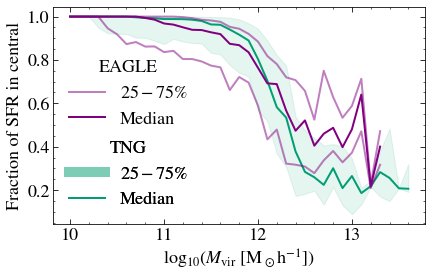

In [44]:
fig, ax1 = plt.subplots()

ax1.fill_between(mhalo_bins, frac_percent[0], frac_percent[2], alpha=0.1, color=palette_tab10[2])
ax1.plot(mhalo_bins, frac_percent[1], alpha=1, color=palette_tab10[2])
for i, p in enumerate(frac_percent):
    if i == 1:
        alpha = 1
        label = "Median"
    else:
        alpha = 0.5
        label="25th-75th percentile"
    ax1.plot(mhalo_bins, frac_percent_eagle[i], alpha=alpha, color="purple", linestyle="solid", label=label)
    #ax1.plot(mhalo_bins, p, alpha=alpha, color=palette_tab10[2])
h, l = ax1.get_legend_handles_labels()
print(h)
leg = ax1.legend(handles=h[:2], labels=["$25-75 \%$", "Median"], loc="center left", title="EAGLE", bbox_to_anchor=(0,0.6))
ax1.add_artist(leg)
tng_light = Line2D([],[],color=palette_tab10[2], alpha=0.3, linestyle="solid", label="$25-75 \%$", linewidth=10)
tng_dark = Line2D([],[],color=palette_tab10[2], alpha=1, linestyle="solid", label="Median")
leg = ax1.legend(handles=[tng_light, tng_dark], loc="lower left", title="TNG")
ax1.add_artist(leg)
# for i, p in enumerate(bh_frac):
#     if i == 1:
#         alpha = 1
#         label = "Median"
#     else:
#         alpha = 0.5
#         label="25th-75th percentile"
#     ax2.plot(mhalo_bins, (p), alpha=alpha, color="grey")
#ax1.plot(mhalo_bins, bh_frac, alpha=alpha, color="grey", label = "logM$_{\mathrm{BH}}$ > 8" )
#plt.legend(loc="upper right", bbox_to_anchor=(1,0.9))

# eag = Line2D([],[],color="purple", linestyle="solid", label="EAGLE")
# tng = Line2D([],[],color=palette_tab10[2], linestyle="solid", label="TNG")


# leg = ax1.legend(handles=[eag, tng], loc="upper right")
# ax1.add_artist(leg)

plt.xlabel(r"$\rm log_{10} $($M_{\mathrm{vir}}$ $\rm[M_\odot h^{-1}$])")
ax1.set_ylabel("Fraction of SFR in central")

#ax2.set_ylabel(r"Fraction with $\rm log_{10} $$M_{\mathrm{BH}}$ > 8")
#ax = plt.gca()
#ax.annotate("SubhaloFlag=1", (0.1,0.5), xycoords="axes fraction", ha="left", weight="bold")

#plt.savefig("../figures/halo_sfr_frac_eagle.pdf", format="pdf", bbox_inches="tight")